<a href="https://colab.research.google.com/github/AJAlnaser/AJAlnaser/blob/main/python-basics/google-colab-r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       vE0     vL0      vC0  gap_EL0  gap_CL0  t_cutin    k_sig    Delta
1 21.86773 27.9894 26.78584 39.32133 18.78068 5.308931 1.911949 1.765568
        T0 lead_brake_time collision collision_time  min_gap  min_ttc final_gap
1 1.769841        11.77468         0             NA 14.59925 4.805681  36.70496
  time       xE       vE aE       xL      vL aL       xC       vC aC       yC
1 0.00 0.000000 21.86773  2 39.32133 27.9894  0 20.54066 26.78584  0 3.699855
2 0.05 1.093387 21.96773  2 40.72080 27.9894  0 21.87995 26.78584  0 3.699841
3 0.10 2.191773 22.06773  2 42.12027 27.9894  0 23.21924 26.78584  0 3.699825
4 0.15 3.295160 22.16773  2 43.51974 27.9894  0 24.55853 26.78584  0 3.699807
5 0.20 4.403546 22.26773  2 44.91921 27.9894  0 25.89783 26.78584  0 3.699788
6 0.25 5.516933 22.36773  2 46.31868 27.9894  0 27.23712 26.78584  0 3.699767
            vyC true_gap perceived_gap desired_gap front_id react_active
1 -0.0002762985 39.32133      41.13564     37.8016       LV        FALSE
2 

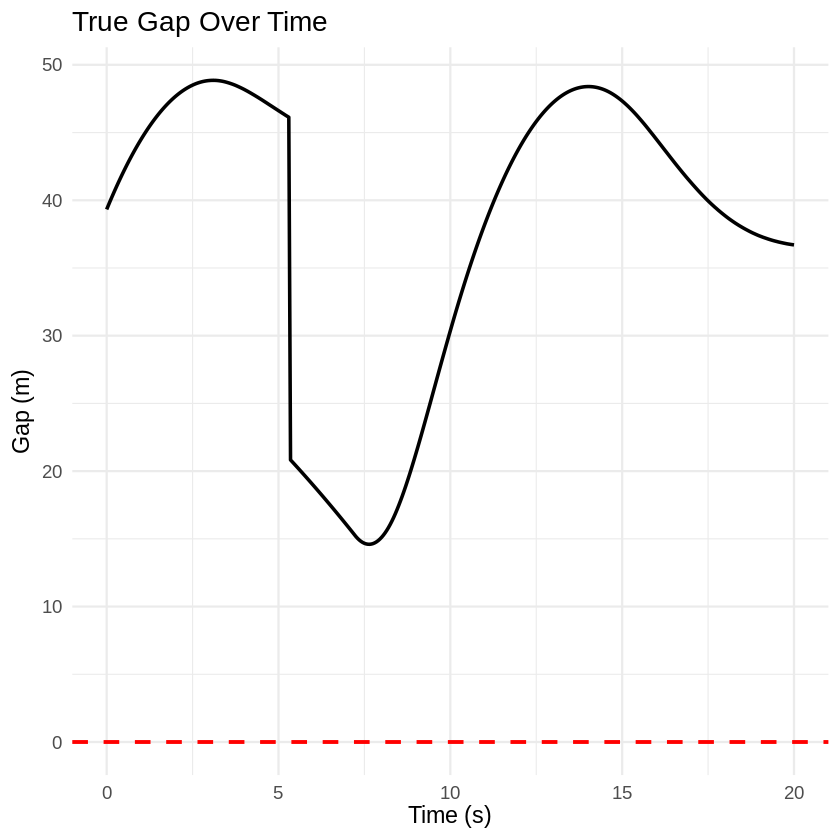

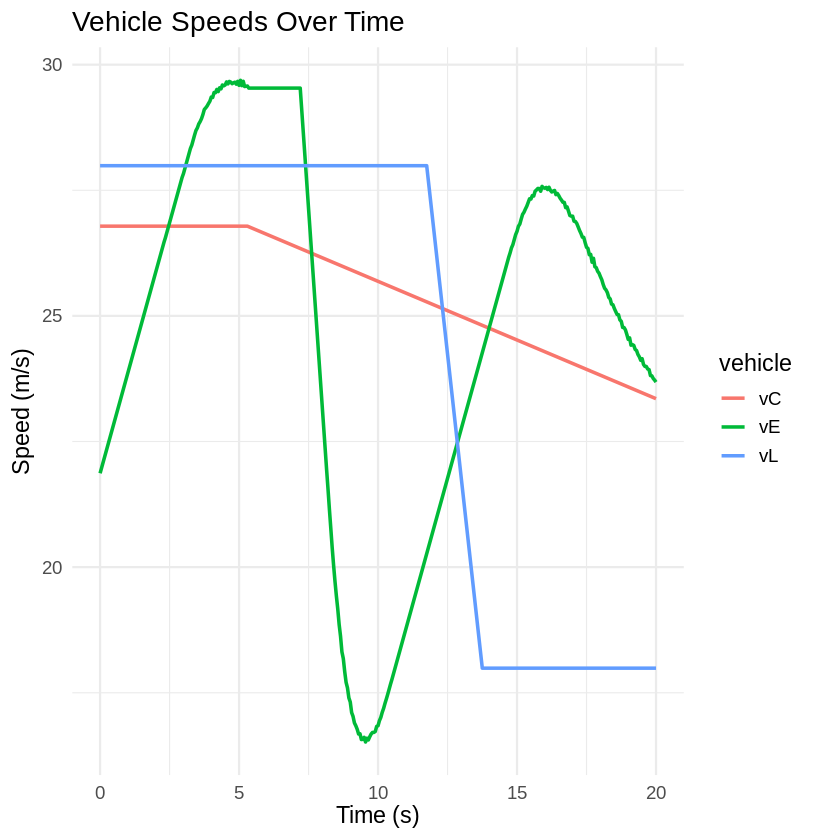

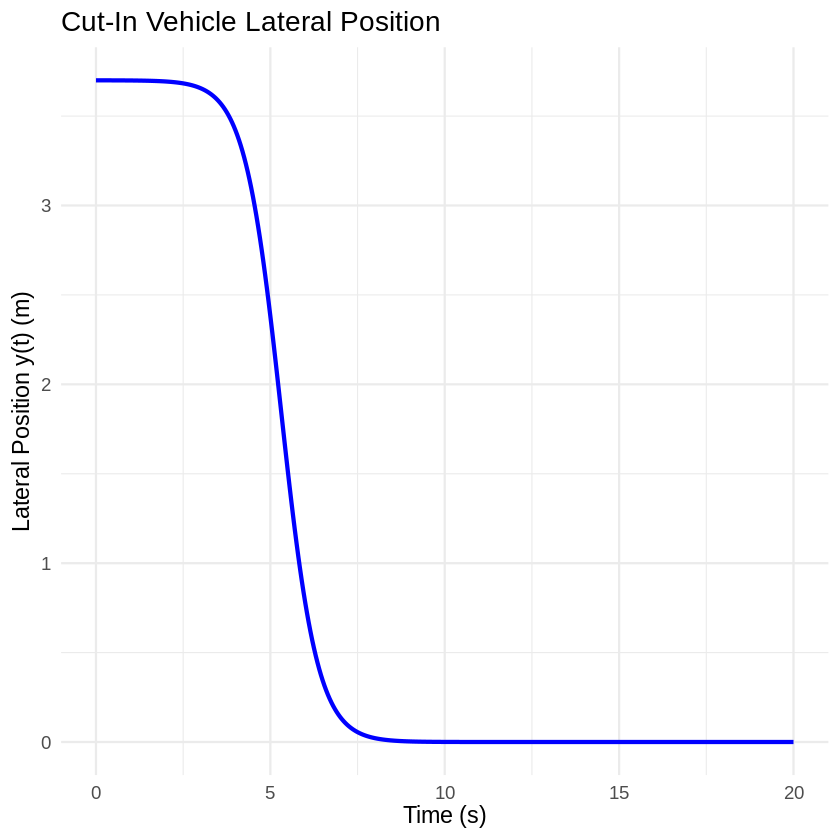

`geom_smooth()` using formula = 'y ~ x'


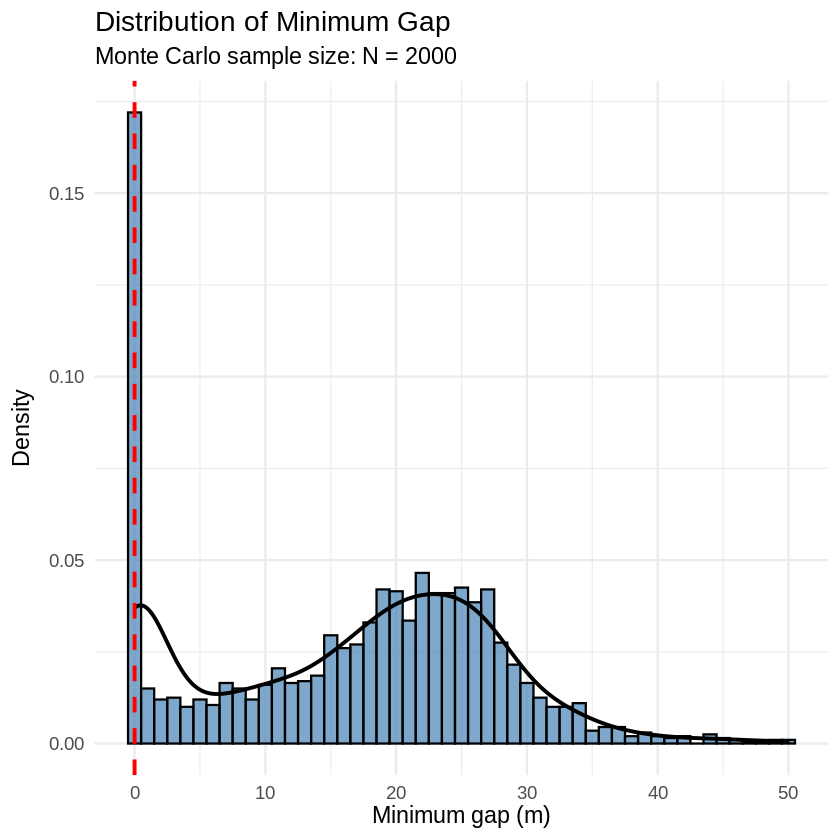

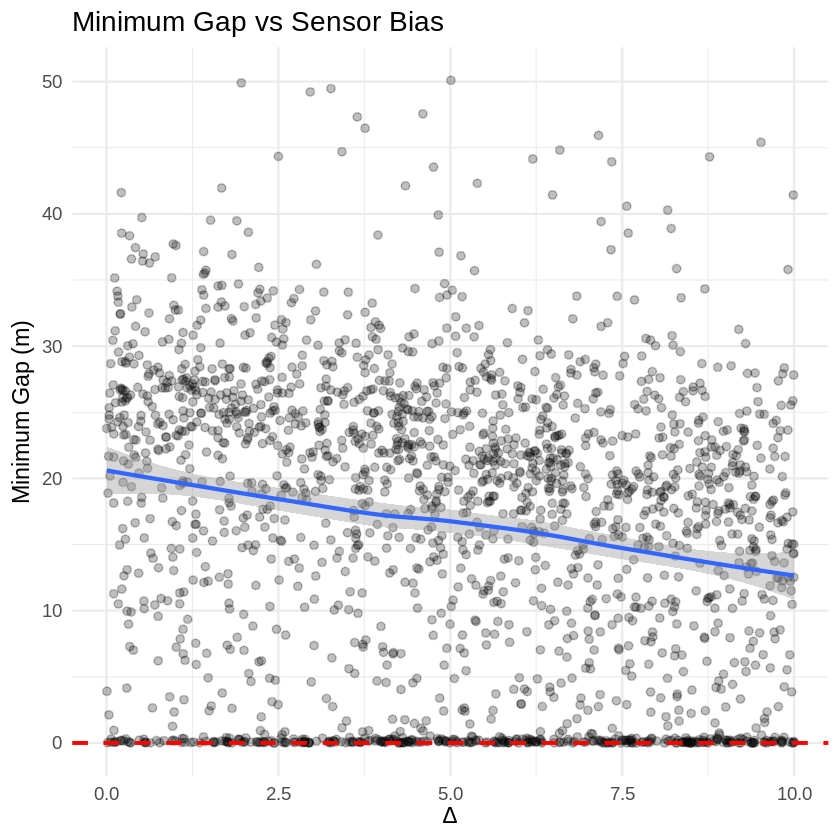

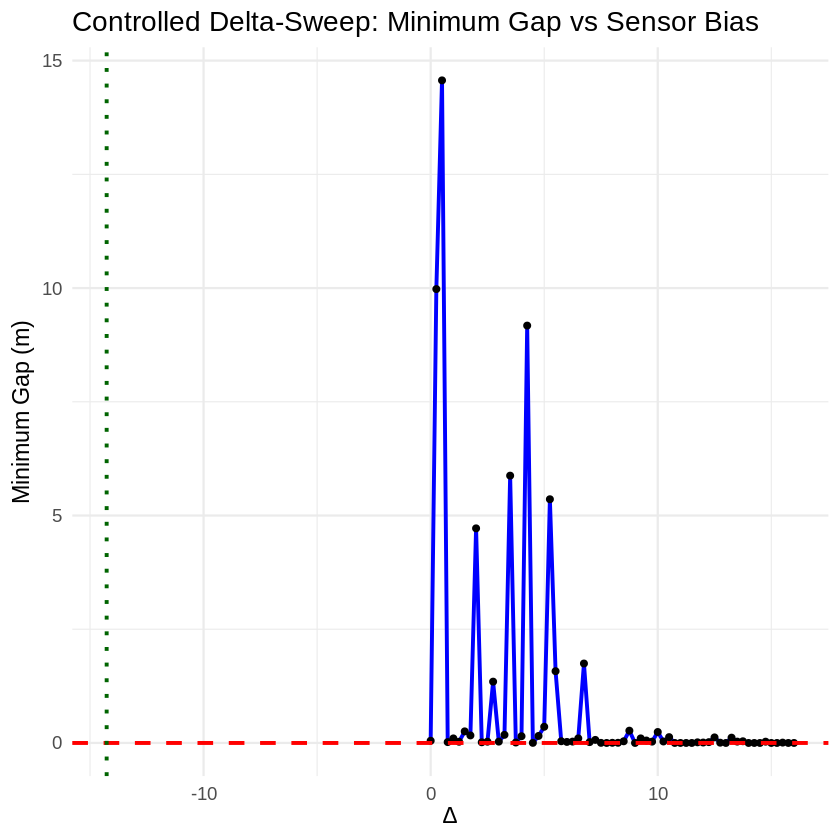

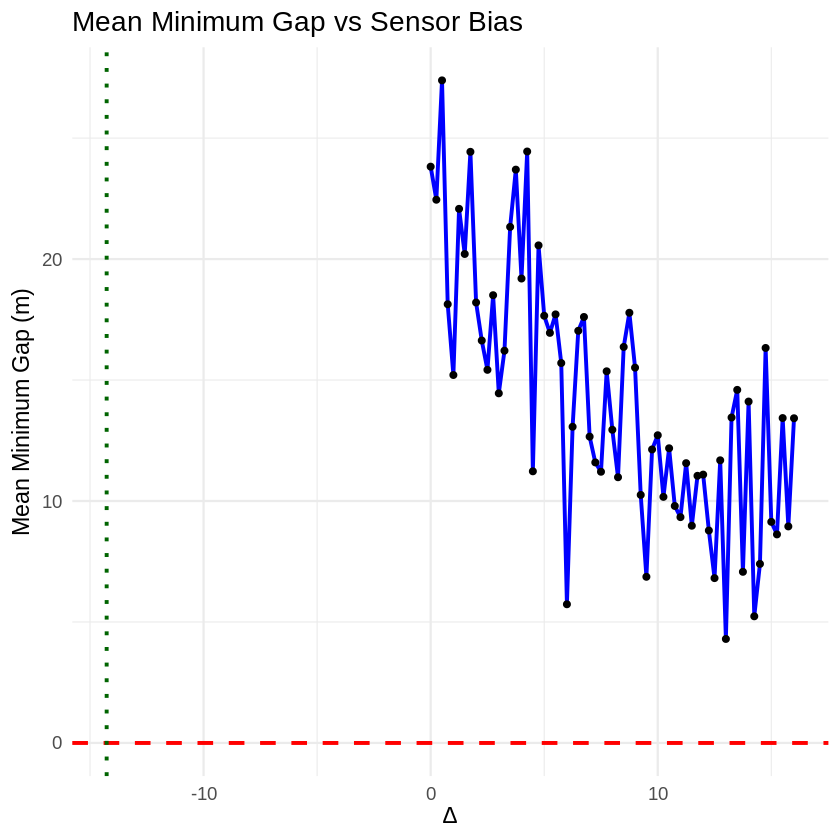

`geom_smooth()` using formula = 'y ~ x'


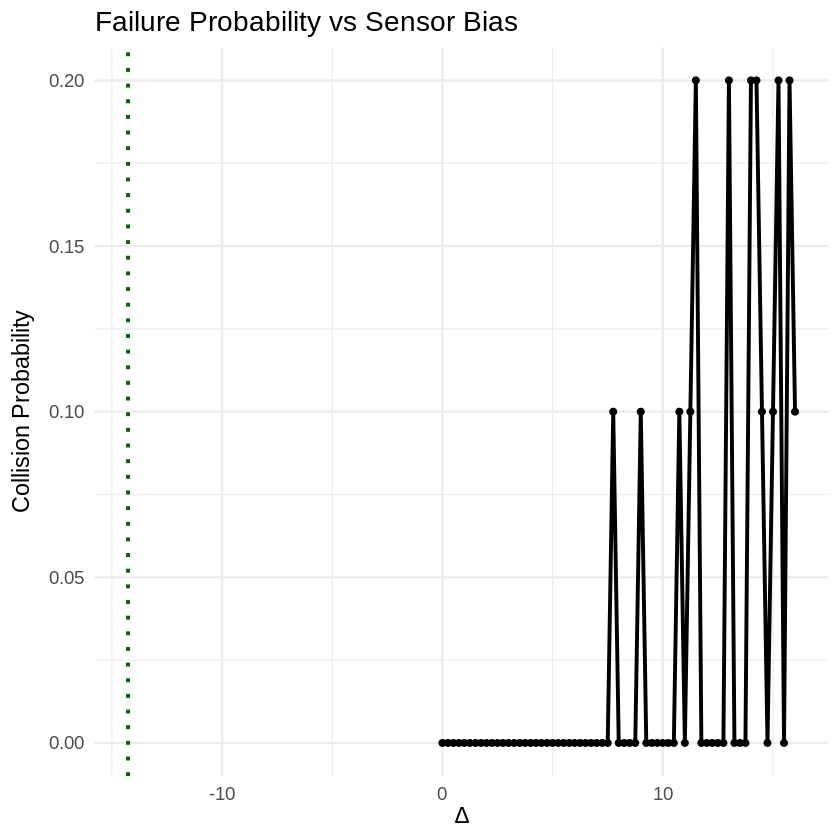

Saved results folder to: /content/results 
Saved zip file to: /content/AVsafetySP2026_results.zip 


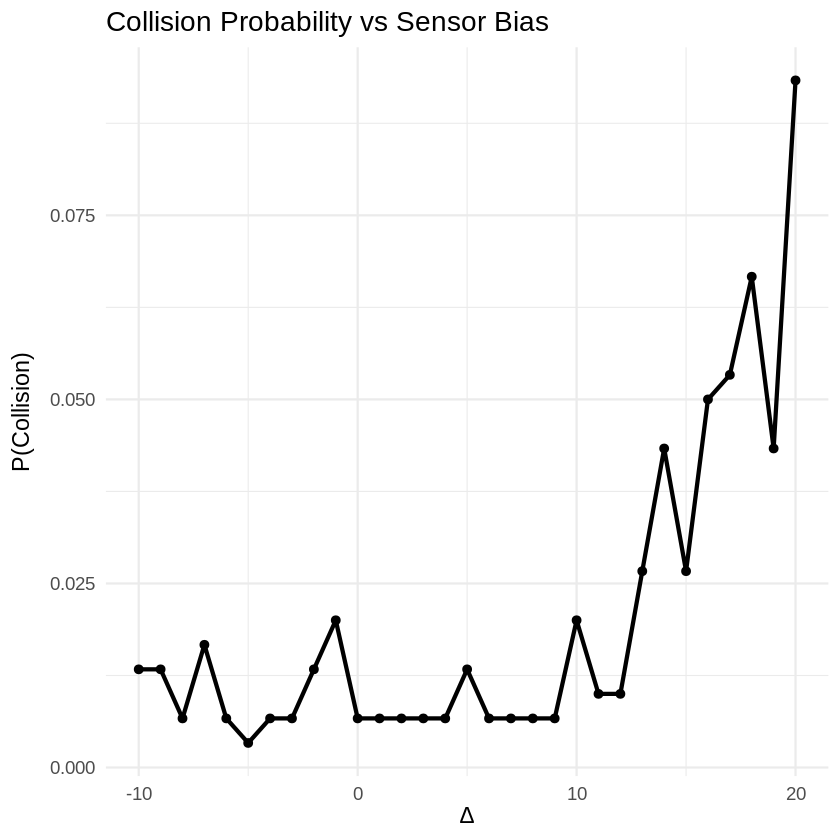

In [1]:
# ============================================================
# R COLAB SETUP
# ============================================================

output_dir <- "/content/results"

needed <- c("ggplot2", "dplyr", "tidyr")
to_install <- needed[!vapply(needed, requireNamespace, quietly = TRUE, FUN.VALUE = logical(1))]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})

if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

# ============================================================
# 1) Uncertainty helpers
# ============================================================

wilson_ci <- function(x, n, conf = 0.95) {
  if (n <= 0) stop("n must be positive")
  z <- qnorm(1 - (1 - conf) / 2)
  p <- x / n
  den <- 1 + z^2 / n
  ctr <- (p + z^2 / (2 * n)) / den
  half <- (z * sqrt((p * (1 - p) + z^2 / (4 * n)) / n)) / den
  c(lower = max(0, ctr - half), upper = min(1, ctr + half))
}

rule_of_three_upper <- function(n, conf = 0.95) {
  -log(1 - conf) / n
}

summarise_binom <- function(x, n, conf = 0.95) {
  ci <- wilson_ci(x, n, conf)
  data.frame(
    n = n,
    x = x,
    p_hat = x / n,
    ci_lo = ci[1],
    ci_hi = ci[2],
    upper_rule3_if_x0 = ifelse(x == 0, rule_of_three_upper(n, conf), NA_real_)
  )
}

# ============================================================
# 2) RSS-style safe-distance helper
# ============================================================

rss_dmin_same_direction <- function(
  v_r, v_f, rho,
  a_max_brake_front = 5,
  a_max_accel_rear = 0,
  a_min_brake_rear = 8
) {
  v_rho <- v_r + rho * a_max_accel_rear
  dmin <- v_r * rho +
    0.5 * a_max_accel_rear * rho^2 +
    v_rho^2 / (2 * a_min_brake_rear) -
    v_f^2 / (2 * a_max_brake_front)
  max(0, dmin)
}

# ============================================================
# 3) Core simulation
# ============================================================

simulate_cutin_pid <- function(
  dt = 0.05,
  T = 20,
  lane_width = 3.7,
  d0 = 5,
  h = 1.5,
  Kp = 0.6,
  Ki = 0.05,
  Kd = 0.25,
  a_min = -8,
  a_max = 2,
  sigma_noise = 0.1,
  seed = NULL,

  vE0 = rnorm(1, 25, 5),
  vL0 = rnorm(1, 24, 3),
  vC0 = rnorm(1, 22, 3),
  gap_EL0 = runif(1, 25, 50),
  gap_CL0 = runif(1, 8, 20),
  t_cutin = runif(1, 5, 10),
  k_sig = runif(1, 1.5, 3.5),
  Delta = runif(1, 0, 10),
  T0 = runif(1, 1, 2),
  lead_brake_time = runif(1, 8, 14),
  aL_brake = -5,
  civ_post_cutin_accel = runif(1, -1, 0.5),

  include_bias = TRUE,
  include_delay = TRUE,
  delta_sign_bias = +1,
  delta_sign_delay = +1,
  delay_factor = 1.5,
  reaction_mode = c("on_hazard", "from_start", "off"),
  hazard_trigger = c("cutin", "cutin_or_lead_brake"),
  delay_hold = c("zero", "previous"),
  controller_switch = c("hysteresis", "hard"),
  switch_margin = 10,
  switch_hyst = 2,
  v_ref = 25,
  Kv = 0.3
) {
  if (!is.null(seed)) set.seed(seed)

  reaction_mode <- match.arg(reaction_mode)
  hazard_trigger <- match.arg(hazard_trigger)
  delay_hold <- match.arg(delay_hold)
  controller_switch <- match.arg(controller_switch)

  n_steps <- floor(T / dt) + 1
  time <- seq(0, T, by = dt)

  xE <- vE <- aE <- numeric(n_steps)
  xL <- vL <- aL <- numeric(n_steps)
  xC <- vC <- aC <- numeric(n_steps)
  yC <- vyC <- numeric(n_steps)

  true_gap <- perceived_gap <- desired_gap <- rep(NA_real_, n_steps)
  front_id <- mode <- rep(NA_character_, n_steps)
  react_active <- rep(FALSE, n_steps)
  t_react_trace <- rep(NA_real_, n_steps)

  xE[1] <- 0
  vE[1] <- max(0, vE0)
  aE[1] <- 0

  xL[1] <- gap_EL0
  vL[1] <- max(0, vL0)
  aL[1] <- 0

  xC[1] <- xL[1] - gap_CL0
  vC[1] <- max(0, vC0)
  aC[1] <- 0

  yC[1] <- lane_width
  vyC[1] <- 0

  y_sigmoid <- function(t) lane_width / (1 + exp(k_sig * (t - t_cutin)))
  vy_sigmoid <- function(t) {
    num <- -(lane_width) * k_sig * exp(k_sig * (t - t_cutin))
    den <- (1 + exp(k_sig * (t - t_cutin)))^2
    num / den
  }

  brake_duration <- 2
  collision <- 0
  collision_time <- NA_real_
  min_gap <- Inf
  min_ttc <- Inf
  e_prev <- 0
  e_int <- 0
  cur_mode <- "gap"
  t_trigger <- NA_real_

  for (k in 2:n_steps) {
    t <- time[k]

    aL[k - 1] <- if (t >= lead_brake_time && t <= lead_brake_time + brake_duration) aL_brake else 0
    aC[k - 1] <- if (t < t_cutin) 0 else civ_post_cutin_accel

    yC[k - 1] <- y_sigmoid(t - dt)
    vyC[k - 1] <- vy_sigmoid(t - dt)

    cutin_in_lane <- yC[k - 1] <= lane_width / 2

    if (cutin_in_lane && xC[k - 1] > xE[k - 1]) {
      front_id[k - 1] <- "CIV"
      d_true <- xC[k - 1] - xE[k - 1]
      v_front <- vC[k - 1]

      if (is.na(t_trigger) && reaction_mode == "on_hazard" &&
          hazard_trigger %in% c("cutin", "cutin_or_lead_brake")) {
        t_trigger <- time[k - 1]
      }
    } else {
      front_id[k - 1] <- "LV"
      d_true <- xL[k - 1] - xE[k - 1]
      v_front <- vL[k - 1]

      if (is.na(t_trigger) && reaction_mode == "on_hazard" &&
          hazard_trigger == "cutin_or_lead_brake" &&
          t >= lead_brake_time && t <= lead_brake_time + brake_duration) {
        t_trigger <- time[k - 1]
      }
    }

    true_gap[k - 1] <- d_true

    Delta_bias <- if (include_bias) delta_sign_bias * Delta else 0
    d_tilde <- d_true + rnorm(1, 0, sigma_noise) + Delta_bias

    perceived_gap[k - 1] <- d_tilde
    desired_gap[k - 1] <- d0 + h * vE[k - 1]

    Delta_delay <- if (include_delay) delta_sign_delay * Delta else 0
    t_react <- max(0, T0 + delay_factor * Delta_delay / max(vE[k - 1], 0.1))
    t_react_trace[k - 1] <- t_react

    if (reaction_mode == "off") {
      react_active[k - 1] <- FALSE
    } else if (reaction_mode == "from_start") {
      react_active[k - 1] <- (t < t_react)
    } else {
      react_active[k - 1] <- (!is.na(t_trigger) && (t - t_trigger < t_react))
    }

    if (react_active[k - 1]) {
      aE[k - 1] <- if (delay_hold == "zero") 0 else aE[max(1, k - 2)]
      mode[k - 1] <- "react_hold"
    } else {
      e <- d_tilde - desired_gap[k - 1]
      e_int <- e_int + e * dt
      e_dot <- (e - e_prev) / dt

      a_gap <- Kp * e + Ki * e_int + Kd * e_dot
      a_speed <- Kv * (v_ref - vE[k - 1])

      if (controller_switch == "hard") {
        cur_mode <- if (d_tilde <= desired_gap[k - 1] + switch_margin) "gap" else "speed"
      } else {
        if (cur_mode == "gap" && d_tilde > desired_gap[k - 1] + switch_margin + switch_hyst) {
          cur_mode <- "speed"
        }
        if (cur_mode == "speed" && d_tilde < desired_gap[k - 1] + switch_margin) {
          cur_mode <- "gap"
        }
      }

      a_cmd <- if (cur_mode == "gap") a_gap else a_speed
      aE[k - 1] <- max(a_min, min(a_max, a_cmd))
      mode[k - 1] <- cur_mode
      e_prev <- e
    }

    vL[k] <- max(0, vL[k - 1] + aL[k - 1] * dt)
    xL[k] <- xL[k - 1] + vL[k - 1] * dt

    vC[k] <- max(0, vC[k - 1] + aC[k - 1] * dt)
    xC[k] <- xC[k - 1] + vC[k - 1] * dt

    vE[k] <- max(0, vE[k - 1] + aE[k - 1] * dt)
    xE[k] <- xE[k - 1] + vE[k - 1] * dt

    yC[k] <- y_sigmoid(t)
    vyC[k] <- vy_sigmoid(t)

    cutin_in_lane_now <- yC[k] <= lane_width / 2

    if (cutin_in_lane_now && xC[k] > xE[k]) {
      d_now <- xC[k] - xE[k]
      v_front_now <- vC[k]
      front_id[k] <- "CIV"
    } else {
      d_now <- xL[k] - xE[k]
      v_front_now <- vL[k]
      front_id[k] <- "LV"
    }

    true_gap[k] <- d_now
    min_gap <- min(min_gap, d_now)

    closing_speed <- vE[k] - v_front_now

    if (closing_speed > 0) {
      ttc_now <- max(0, d_now / closing_speed)
      min_ttc <- min(min_ttc, ttc_now)
    }

    if (d_now <= 0 && collision == 0) {
      collision <- 1

      d_prev <- true_gap[k - 1]

      if (!is.na(d_prev) && d_prev > 0) {
        frac <- d_prev / (d_prev - d_now)
        collision_time <- time[k - 1] + frac * dt
      } else {
        collision_time <- t
      }

      true_gap[k] <- 0
      min_gap <- 0
      min_ttc <- 0

      if (k < n_steps) {
        xE[(k + 1):n_steps] <- xE[k]
        vE[(k + 1):n_steps] <- vE[k]
        aE[(k + 1):n_steps] <- 0

        xL[(k + 1):n_steps] <- xL[k]
        vL[(k + 1):n_steps] <- vL[k]
        aL[(k + 1):n_steps] <- 0

        xC[(k + 1):n_steps] <- xC[k]
        vC[(k + 1):n_steps] <- vC[k]
        aC[(k + 1):n_steps] <- 0

        yC[(k + 1):n_steps] <- yC[k]
        vyC[(k + 1):n_steps] <- 0

        true_gap[(k + 1):n_steps] <- 0
        perceived_gap[(k + 1):n_steps] <- perceived_gap[k]
        desired_gap[(k + 1):n_steps] <- d0 + h * vE[k]
        front_id[(k + 1):n_steps] <- front_id[k]
        mode[(k + 1):n_steps] <- "post_collision"
      }

      break
    }
  }

  if (is.infinite(min_ttc)) min_ttc <- NA_real_

  summary <- data.frame(
    vE0 = vE0,
    vL0 = vL0,
    vC0 = vC0,
    gap_EL0 = gap_EL0,
    gap_CL0 = gap_CL0,
    t_cutin = t_cutin,
    k_sig = k_sig,
    Delta = Delta,
    T0 = T0,
    lead_brake_time = lead_brake_time,
    collision = collision,
    collision_time = collision_time,
    min_gap = min_gap,
    min_ttc = min_ttc,
    final_gap = tail(true_gap, 1)
  )

  traj <- data.frame(
    time = time,
    xE = xE, vE = vE, aE = aE,
    xL = xL, vL = vL, aL = aL,
    xC = xC, vC = vC, aC = aC,
    yC = yC, vyC = vyC,
    true_gap = true_gap,
    perceived_gap = perceived_gap,
    desired_gap = desired_gap,
    front_id = front_id,
    react_active = react_active,
    t_react = t_react_trace,
    mode = mode
  )

  list(summary = summary, traj = traj, t_trigger = t_trigger)
}

# ============================================================
# 4) Monte Carlo and Delta sweeps
# ============================================================

run_monte_carlo <- function(
  N = 2000,
  base_seed = 123,
  sampling_mode = c("legacy_stream", "per_run_seed"),
  sim_args = list()
) {
  sampling_mode <- match.arg(sampling_mode)
  out <- vector("list", N)

  if (sampling_mode == "legacy_stream") {
    set.seed(base_seed)
    for (i in seq_len(N)) {
      sim <- do.call(simulate_cutin_pid, sim_args)
      out[[i]] <- cbind(sim$summary, run = i, seed_run = NA_integer_)
    }
  } else {
    for (i in seq_len(N)) {
      s <- base_seed + i
      sim <- do.call(simulate_cutin_pid, c(list(seed = s), sim_args))
      out[[i]] <- cbind(sim$summary, run = i, seed_run = s)
    }
  }

  bind_rows(out)
}

run_delta_sweep <- function(
  Delta_values,
  n_rep = 1,
  base_seed = 9000,
  sampling_mode = c("per_run_seed", "legacy_stream"),
  sim_args = list()
) {
  sampling_mode <- match.arg(sampling_mode)
  out <- vector("list", length(Delta_values) * n_rep)
  idx <- 1

  if (sampling_mode == "legacy_stream") set.seed(base_seed)

  for (d in Delta_values) {
    for (j in seq_len(n_rep)) {
      s <- if (sampling_mode == "per_run_seed") base_seed + j + as.integer(round(d * 1000)) else NULL
      sim <- do.call(simulate_cutin_pid, c(list(Delta = d, seed = s), sim_args))

      out[[idx]] <- data.frame(
        Delta = d,
        rep = j,
        seed_run = s,
        collision = sim$summary$collision,
        collision_time = sim$summary$collision_time,
        min_gap = sim$summary$min_gap,
        min_ttc = sim$summary$min_ttc,
        final_gap = sim$summary$final_gap,
        t_trigger = sim$t_trigger
      )

      idx <- idx + 1
    }
  }

  bind_rows(out)
}

summarise_collision <- function(df, conf = 0.95) {
  summarise_binom(sum(df$collision), nrow(df), conf)
}

summarise_per_delta <- function(delta_df, conf = 0.95) {
  delta_df %>%
    group_by(Delta) %>%
    summarise(
      n = n(),
      x = sum(collision),
      p_hat = mean(collision),
      ci_lo = wilson_ci(x, n, conf)[1],
      ci_hi = wilson_ci(x, n, conf)[2],
      upper_rule3_if_x0 = ifelse(x == 0, rule_of_three_upper(n, conf), NA_real_),
      min_gap_min = min(min_gap),
      min_gap_mean = mean(min_gap),
      min_ttc_min = suppressWarnings(min(min_ttc, na.rm = TRUE)),
      .groups = "drop"
    )
}

# ============================================================
# 5) Plots
# ============================================================

plot_true_gap <- function(sim) {
  ggplot(sim$traj, aes(time, true_gap)) +
    geom_line(linewidth = 1) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1.1) +
    theme_minimal(base_size = 14) +
    labs(title = "True Gap Over Time", x = "Time (s)", y = "Gap (m)")
}

plot_vehicle_speeds <- function(sim) {
  speed_df <- sim$traj %>%
    select(time, vE, vL, vC) %>%
    pivot_longer(cols = c(vE, vL, vC), names_to = "vehicle", values_to = "speed")

  ggplot(speed_df, aes(time, speed, color = vehicle)) +
    geom_line(linewidth = 1) +
    theme_minimal(base_size = 14) +
    labs(title = "Vehicle Speeds Over Time", x = "Time (s)", y = "Speed (m/s)")
}

plot_lateral_position <- function(sim) {
  ggplot(sim$traj, aes(time, yC)) +
    geom_line(linewidth = 1.2, color = "blue") +
    theme_minimal(base_size = 14) +
    labs(title = "Cut-In Vehicle Lateral Position", x = "Time (s)", y = "Lateral Position y(t) (m)")
}

plot_hist_min_gap <- function(df) {
  ggplot(df, aes(min_gap)) +
    geom_histogram(aes(y = after_stat(density)), binwidth = 1, fill = "steelblue", color = "black", alpha = 0.7) +
    geom_density(linewidth = 1.1) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1.1) +
    theme_minimal(base_size = 14) +
    labs(
      title = "Distribution of Minimum Gap",
      subtitle = paste("Monte Carlo sample size: N =", nrow(df)),
      x = "Minimum gap (m)",
      y = "Density"
    )
}

plot_min_gap_vs_Delta <- function(df) {
  ggplot(df, aes(Delta, min_gap)) +
    geom_point(alpha = 0.25) +
    geom_smooth(method = "loess", se = TRUE, linewidth = 1.2) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1.1) +
    theme_minimal(base_size = 14) +
    labs(title = "Minimum Gap vs Sensor Bias", x = expression(Delta), y = "Minimum Gap (m)")
}

plot_controlled_sweep <- function(per_delta, Delta_star = NULL) {
  p <- ggplot(per_delta, aes(Delta, min_gap_min)) +
    geom_line(color = "blue", linewidth = 1.1) +
    geom_point(color = "black", size = 1.4) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1.1) +
    theme_minimal(base_size = 14) +
    labs(
      title = "Controlled Delta-Sweep: Minimum Gap vs Sensor Bias",
      x = expression(Delta),
      y = "Minimum Gap (m)"
    )

  if (!is.null(Delta_star) && is.finite(Delta_star)) {
    p <- p + geom_vline(xintercept = Delta_star, linetype = "dotted", color = "darkgreen", linewidth = 1.1)
  }

  p
}

plot_mean_gap_per_delta <- function(per_delta, Delta_star = NULL) {
  p <- ggplot(per_delta, aes(Delta, min_gap_mean)) +
    geom_line(color = "blue", linewidth = 1.1) +
    geom_point(color = "black", size = 1.4) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "red", linewidth = 1.1) +
    theme_minimal(base_size = 14) +
    labs(
      title = "Mean Minimum Gap vs Sensor Bias",
      x = expression(Delta),
      y = "Mean Minimum Gap (m)"
    )

  if (!is.null(Delta_star) && is.finite(Delta_star)) {
    p <- p + geom_vline(xintercept = Delta_star, linetype = "dotted", color = "darkgreen", linewidth = 1.1)
  }

  p
}

plot_failure_prob_per_delta <- function(per_delta, Delta_star = NULL) {
  p <- ggplot(per_delta, aes(Delta, p_hat)) +
    geom_line(color = "black", linewidth = 1.1) +
    geom_point(size = 1.4) +
    theme_minimal(base_size = 14) +
    labs(
      title = "Failure Probability vs Sensor Bias",
      x = expression(Delta),
      y = "Collision Probability"
    )

  if (!is.null(Delta_star) && is.finite(Delta_star)) {
    p <- p + geom_vline(xintercept = Delta_star, linetype = "dotted", color = "darkgreen", linewidth = 1.1)
  }

  p
}

# ============================================================
# 6) Analytical threshold helpers
# ============================================================

compute_delta_star_rss <- function(
  sim,
  T0 = NULL,
  a_max_brake_front = 5,
  a_max_accel_rear = 0,
  a_min_brake_rear = 8
) {
  traj <- sim$traj
  idx <- which(traj$front_id == "CIV")[1]

  if (length(idx) == 0 || is.na(idx)) return(NA_real_)

  d_h <- traj$true_gap[idx]
  v_r <- traj$vE[idx]
  v_f <- traj$vC[idx]
  rho <- if (is.null(T0)) sim$summary$T0[1] else T0

  dmin <- rss_dmin_same_direction(
    v_r = v_r,
    v_f = v_f,
    rho = rho,
    a_max_brake_front = a_max_brake_front,
    a_max_accel_rear = a_max_accel_rear,
    a_min_brake_rear = a_min_brake_rear
  )

  data.frame(
    t_hazard = traj$time[idx],
    d_h = d_h,
    v_r = v_r,
    v_f = v_f,
    rho = rho,
    dmin_rss = dmin,
    Delta_star_rss = d_h - dmin
  )
}

estimate_empirical_delta_star <- function(delta_df, eps_gap = 0) {
  out <- delta_df %>%
    group_by(Delta) %>%
    summarise(any_fail = any(collision == 1 | min_gap <= eps_gap), .groups = "drop") %>%
    filter(any_fail)

  if (nrow(out) == 0) return(NA_real_)

  min(out$Delta)
}

# ============================================================
# 7) Paper-grade recommended settings
# ============================================================

paper_sim_args <- list(
  include_bias = TRUE,
  include_delay = TRUE,
  delay_factor = 1.5,
  reaction_mode = "on_hazard",
  hazard_trigger = "cutin",
  delay_hold = "zero",
  controller_switch = "hysteresis",
  sigma_noise = 0.1
)

paper_sweep_args <- modifyList(paper_sim_args, list(sigma_noise = 0))

# ============================================================
# 8) Run everything
# ============================================================

run_paper_study <- function(
  N_mc = 2000,
  Delta_values = seq(0, 16, by = 0.25),
  n_rep = 10
) {
  set.seed(1)

  sim1 <- do.call(simulate_cutin_pid, c(list(seed = 1), paper_sim_args))

  mc_df <- run_monte_carlo(
    N = N_mc,
    base_seed = 123,
    sampling_mode = "legacy_stream",
    sim_args = paper_sim_args
  )

  delta_df_rep <- run_delta_sweep(
    Delta_values = Delta_values,
    n_rep = n_rep,
    base_seed = 9000,
    sampling_mode = "per_run_seed",
    sim_args = paper_sweep_args
  )

  per_delta <- summarise_per_delta(delta_df_rep)
  rss_tbl <- compute_delta_star_rss(sim1)
  Delta_star_rss <- if (all(is.na(rss_tbl))) NA_real_ else rss_tbl$Delta_star_rss[1]
  Delta_star_emp <- estimate_empirical_delta_star(delta_df_rep)

  list(
    sim1 = sim1,
    mc_df = mc_df,
    mc_collision_summary = summarise_collision(mc_df),
    delta_df_rep = delta_df_rep,
    per_delta = per_delta,
    rss_tbl = rss_tbl,
    Delta_star_rss = Delta_star_rss,
    Delta_star_emp = Delta_star_emp,
    plots = list(
      true_gap = plot_true_gap(sim1),
      speeds = plot_vehicle_speeds(sim1),
      lateral = plot_lateral_position(sim1),
      hist_min_gap = plot_hist_min_gap(mc_df),
      min_gap_vs_Delta = plot_min_gap_vs_Delta(mc_df),
      controlled_sweep = plot_controlled_sweep(per_delta, Delta_star_rss),
      mean_gap = plot_mean_gap_per_delta(per_delta, Delta_star_rss),
      failure_prob = plot_failure_prob_per_delta(per_delta, Delta_star_rss)
    )
  )
}

# ============================================================
# 9) Example run
# ============================================================

results <- run_paper_study()

print(results$sim1$summary)
print(head(results$sim1$traj))
print(results$mc_collision_summary)
print(summary(results$mc_df$min_gap))
print(results$rss_tbl)

cat("Empirical Delta* =", results$Delta_star_emp, "\n")

print(results$plots$true_gap)
print(results$plots$speeds)
print(results$plots$lateral)
print(results$plots$hist_min_gap)
print(results$plots$min_gap_vs_Delta)
print(results$plots$controlled_sweep)
print(results$plots$mean_gap)
print(results$plots$failure_prob)

# ============================================================
# 10) Save output files
# ============================================================

write.csv(results$mc_df, file.path(output_dir, "mc_results.csv"), row.names = FALSE)
write.csv(results$delta_df_rep, file.path(output_dir, "delta_sweep_raw.csv"), row.names = FALSE)
write.csv(results$per_delta, file.path(output_dir, "delta_summary.csv"), row.names = FALSE)
write.csv(results$sim1$traj, file.path(output_dir, "single_trajectory.csv"), row.names = FALSE)

write.csv(results$sim1$summary, file.path(output_dir, "single_summary.csv"), row.names = FALSE)
write.csv(results$mc_collision_summary, file.path(output_dir, "mc_collision_summary.csv"), row.names = FALSE)
write.csv(results$rss_tbl, file.path(output_dir, "rss_threshold.csv"), row.names = FALSE)

write.csv(
  data.frame(Delta_star_emp = results$Delta_star_emp),
  file.path(output_dir, "delta_star_empirical.csv"),
  row.names = FALSE
)

save_plot <- function(plot, filename, width = 8, height = 6, dpi = 300) {
  ggsave(
    filename = file.path(output_dir, filename),
    plot = plot,
    width = width,
    height = height,
    dpi = dpi
  )
}

save_plot(results$plots$true_gap, "true_gap.pdf")
save_plot(results$plots$speeds, "vehicle_speeds.pdf")
save_plot(results$plots$lateral, "lateral_position.pdf")
save_plot(results$plots$hist_min_gap, "min_gap_distribution.pdf")
save_plot(results$plots$min_gap_vs_Delta, "min_gap_vs_delta.pdf")
save_plot(results$plots$controlled_sweep, "controlled_sweep.pdf")
save_plot(results$plots$mean_gap, "mean_gap_vs_delta.pdf")
save_plot(results$plots$failure_prob, "failure_probability.pdf")

# ============================================================
# 11) Estimate P(collision | Delta)
# ============================================================

delta_grid <- seq(-10, 20, by = 1)
N_per_delta <- 300

delta_prob_results <- data.frame()

for (d in delta_grid) {
  collisions <- numeric(N_per_delta)

  for (i in seq_len(N_per_delta)) {
    sim <- simulate_cutin_pid(
      vE0 = runif(1, 20, 40),
      vL0 = runif(1, 15, 30),
      vC0 = runif(1, 20, 30),
      gap_EL0 = runif(1, 25, 50),
      gap_CL0 = runif(1, 8, 20),
      t_cutin = runif(1, 5, 10),
      k_sig = runif(1, 1.5, 3.5),
      Delta = d,
      T0 = runif(1, 1.0, 2.0),
      lead_brake_time = runif(1, 8, 12)
    )

    collisions[i] <- sim$summary$collision[1]
  }

  delta_prob_results <- rbind(
    delta_prob_results,
    data.frame(
      Delta = d,
      collision_prob = mean(collisions)
    )
  )
}

write.csv(
  delta_prob_results,
  file.path(output_dir, "collision_probability_by_delta.csv"),
  row.names = FALSE
)

p_collision_delta <- ggplot(delta_prob_results, aes(x = Delta, y = collision_prob)) +
  geom_line(linewidth = 1.2, color = "black") +
  geom_point() +
  theme_minimal(base_size = 14) +
  labs(
    title = "Collision Probability vs Sensor Bias",
    x = expression(Delta),
    y = "P(Collision)"
  )

print(p_collision_delta)

save_plot(p_collision_delta, "collision_probability_by_delta.pdf")

# ============================================================
# 12) Zip all outputs for easy download from Colab
# ============================================================

zip_file <- "/content/AVsafetySP2026_results.zip"

if (dir.exists(output_dir)) {
  old_wd <- getwd()
  setwd(dirname(output_dir))
  utils::zip(zipfile = zip_file, files = basename(output_dir))
  setwd(old_wd)

  cat("Saved results folder to:", output_dir, "\n")
  cat("Saved zip file to:", zip_file, "\n")
}